In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def magS(s1,s2):
    m = s2/s1
    return m

In [3]:
def magZ(z1,z2):
    """
    z1: focus-to-sample distance 
    z2: sample-to-detector distance
    f: focal length
    """
    M = (z1 + z2)/z1
    return M

In [4]:
def divergence(s,f):
    """
    s: size of focusing optic
    f: focal length
    """
    d = np.arctan(s/(2*f))
    return d

In [5]:
def sConstantD(f,d):
    """
    f: focal length
    d: divergence
    """
    s = (2*f*np.tan(d))
    return s

In [6]:
def propDistForBeamSize(f,s1,s2,beforeFocus=False):
    """
    f: focal length
    s1: size of optic
    s2: size of desired illumination
    beforeFocus: Specify whether distance is before or after focus. if True: z<f. if False: z>f
    """
    if beforeFocus:
        z = f*(1 - (s2/s1))
    else:
        z = f*((s2/s1) + 2)
    return z

In [7]:
s = 500e-6    # source size at optic
f = 0.010888  # focal length
z1 = 0.0015-f     # focus-to-sample distance
z2 = 400e-6   # sample-to-detector distance
sm = 80e-6    # size of grating mask (actually 37.5e-6)

ds = np.linspace(50e-6,500e-6,5)
df = [0.0010888,0.0022,0.010888,0.022,0.03]

M = magZ(z1,z2)
print(f'M: {M}')
d = divergence(s,f)
print(f'div: {d}')

#F = [fConstantD(S,d) for S in ds]
#print(f'(s,f): {[(S,_f) for S,_f in zip(ds,F)]}')

S = [sConstantD(_f,d) for _f in df]
Z = [propDistForBeamSize(_f,_S,sm,False) for _f,_S in zip(df,S)]
print(Z)
print(f'(f,s,z) (mm,um,m): {[(_f*1e3,_S*1e6,_Z) for _f,_S,_Z in zip(df,S,Z)]}')

M: 0.9573924158500213
div: 0.02295702422025013
[0.00391968, 0.00614208, 0.02351808, 0.04574208, 0.061742080000000005]
(f,s,z) (mm,um,m): [(1.0888, 50.0, 0.00391968), (2.2, 101.02865540044087, 0.00614208), (10.888, 500.0, 0.02351808), (22.0, 1010.2865540044086, 0.04574208), (30.0, 1377.6634827332844, 0.061742080000000005)]


In [8]:
z = propDistForBeamSize(f=1.0888e-3,s1=50e-6,s2=40e-6,beforeFocus=True)
z

0.00021775999999999995

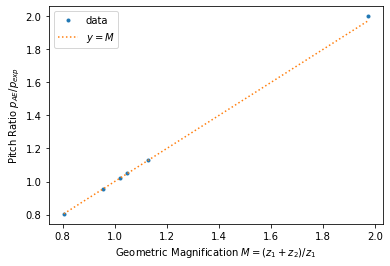

In [9]:
F= [1.0888e-3,1.0888e-3,10.888e-3,10.888e-3,10.888e-3,1.0888e-3]
Z1 = [411.2e-6,0.010888,0.004112,0.00174208,-0.0043552,-0.00087104]
Z2 = [0.0004,204.4392488e-6,190e-6,220e-6,200e-6,170e-6]
P = [200,102,105,113,95.5,80.4]
M = [magZ(a1,a2) for a1,a2 in zip(Z1,Z2)]
pitch = 50

plt.plot(M,[p/(2*pitch) for p in P],'.', label='data')
plt.plot(sorted(M),sorted(M), ':', label='$y=M$') #[50.5*m for m in sorted(M)]
plt.xlabel('Geometric Magnification $M = (z_1 + z_2)/z_1$')
plt.ylabel('Pitch Ratio $p_{AE}/p_{exp}$')
plt.legend()
plt.savefig('pitchVmag.png')
plt.show()

In [10]:
100/(M[0])

50.69033530571993

In [11]:
M

[1.9727626459143968,
 1.0187765658339456,
 1.046206225680934,
 1.1262858192505512,
 0.9540778839088906,
 0.8048310066127847]